In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../notebooks/DATA/data_banknote_authentication.csv')

In [3]:
df.head()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


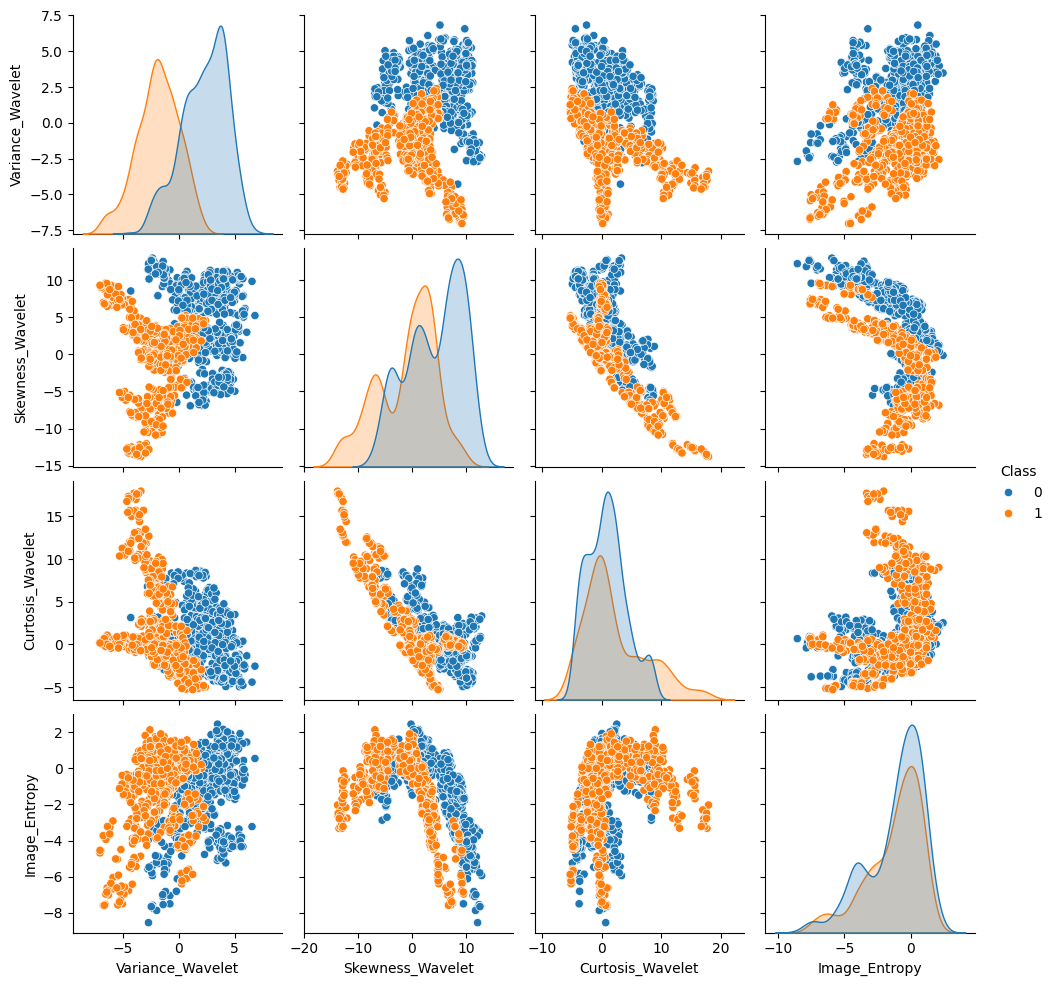

In [4]:
sns.pairplot(data=df, hue='Class')

In [5]:
X = df.drop('Class', axis=1)

In [6]:
y = df['Class']

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [9]:
from sklearn.model_selection import GridSearchCV

In [10]:
from sklearn.ensemble import RandomForestClassifier

In [11]:
n_estimators = [64,100,128,200]
max_features = [0.33, 2, 3, 4]
bootstrap = [True, False]
oob_score = [True, False]


In [12]:
param_grid = {
    'n_estimators': n_estimators,
    'max_features': max_features,
    'bootstrap': bootstrap,
    'oob_score': oob_score
}

In [13]:
rfc = RandomForestClassifier()

In [14]:
grid_model = GridSearchCV(rfc, param_grid=param_grid)

In [15]:
grid_model.fit(X_train, y_train)

C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
80 fits failed out of a total of 320.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\Asus\AppData\L

,estimator,RandomForestClassifier()
,param_grid,"{'bootstrap': [True, False], 'max_features': [0.33, 2, ...], 'n_estimators': [64, 100, ...], 'oob_score': [True, False]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,128


In [16]:
grid_model.best_params_

{'bootstrap': False,
 'max_features': 2,
 'n_estimators': 128,
 'oob_score': False}

In [17]:
rfc = RandomForestClassifier(max_features=2, n_estimators=128, oob_score=True)

In [18]:
rfc.fit(X_train, y_train)

,n_estimators,128
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,2
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [19]:
rfc.oob_score_

0.9914236706689536

In [20]:
y_pred = rfc.predict(X_test)

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       111
           1       0.99      0.99      0.99        95

    accuracy                           0.99       206
   macro avg       0.99      0.99      0.99       206
weighted avg       0.99      0.99      0.99       206



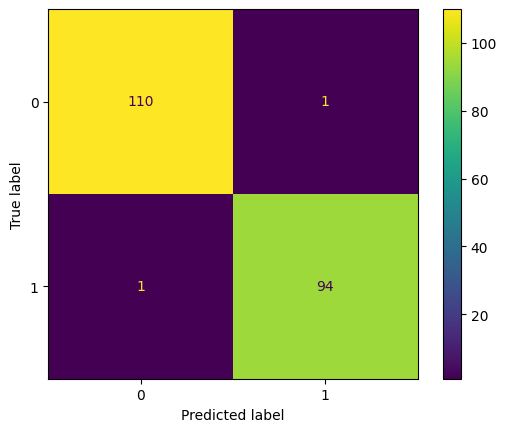

In [23]:
ConfusionMatrixDisplay.from_estimator(rfc, X_test, y_test)

In [25]:
from sklearn.metrics import accuracy_score

In [26]:
errors = []
misclassifications = []

for n in range(1,200):

    rfc = RandomForestClassifier(n_estimators=n, max_features=2)
    rfc.fit(X_train, y_train)
    y_pred = rfc.predict(X_test)

    err = 1-accuracy_score(y_test, y_pred)
    n_missed = np.sum(y_pred != y_test)

    errors.append(err)
    misclassifications.append(n_missed)

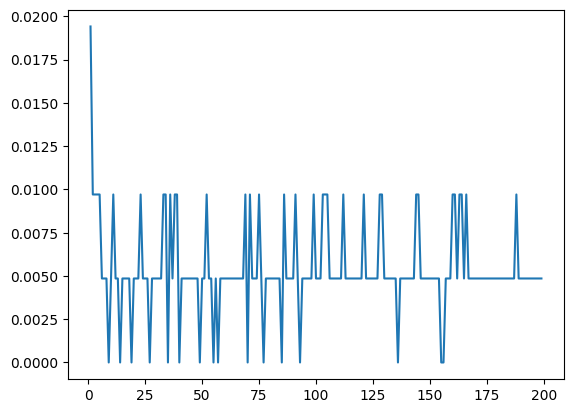

In [27]:
plt.plot(range(1,200), errors)

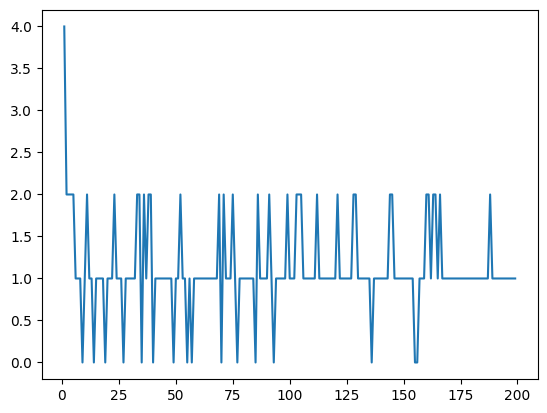

In [28]:
plt.plot(range(1,200), misclassifications)

In [29]:
rfc = RandomForestClassifier(max_features=2, n_estimators=15, oob_score=False)

In [30]:
rfc.fit(X_train, y_train)

,n_estimators,15
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,2
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
y_pred = rfc.predict(X_test)

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       111
           1       1.00      0.99      0.99        95

    accuracy                           1.00       206
   macro avg       1.00      0.99      1.00       206
weighted avg       1.00      1.00      1.00       206



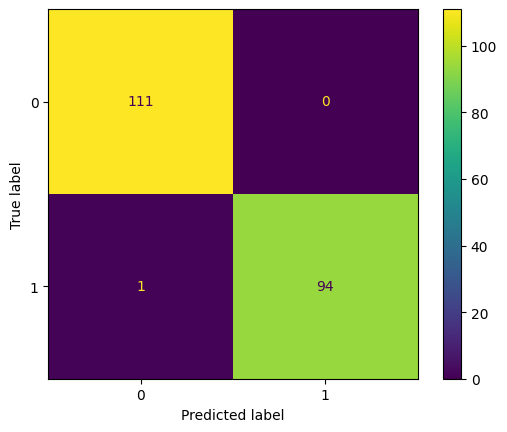

In [34]:
ConfusionMatrixDisplay.from_estimator(rfc, X_test, y_test)